# Operations, Monitoring & Evidence
Covers **Stage 4.** Complete every `# TODO` in this notebook **and** in the `src/` modules it imports. 
- Each stage opens with a **sub-task checklist**
- Capture any repo-generated evidence (MLflow UI, Docker build, CI run, drift report) as screenshots/summaries **inside the notebook/report**.

**File ownership** — 
- *Provided:* `config.py`, `src/evaluate.py`. 
- *Provided to extend:* `src/monitoring.py`, `src/retrain.py`, `src/model.py` (EmbeddingExtractor). 
- *You build:* this notebook.

### 0. Setup

In [3]:
import config, json
# TODO: load artifacts/drift_summary.json after running src.monitoring
!python -m src.monitoring

[drift] statistical: 5/5 features drifted (share 1.00) | embedding PSI 1.2273 | confidence 0.820→0.787 (drop 0.0336) | retrain=True


In [7]:
import warnings
warnings.filterwarnings("ignore")

import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import config

load = lambda p: json.loads(Path(p).read_text())

In [8]:
with open(config.ARTIFACT_DIR / "drift_summary.json", "r") as f:
    drift = json.load(f)
print(drift)

{'statistical_drift': {'n_features': 5, 'n_drifted': 5, 'drift_share': 1.0, 'dataset_drift': True, 'feature_psi': {'brightness': 1.1479, 'contrast': 1.1132, 'edge_density': 1.384, 'sharpness': 1.3, 'mean_intensity': 1.1479}}, 'embedding_drift': {'psi': 1.2273, 'threshold': 0.1, 'drifted': True}, 'confidence': {'reference_mean': 0.8204, 'current_mean': 0.7869, 'drop': 0.0336, 'alert': False}, 'retrain_recommended': True}


## **Stage 4.1 — Prediction Logging & Confidence Monitoring** <font color="red">[5 marks]</font>

- **4.1.1 — Prediction logging with timestamp [2]** — *to be done in this notebook and the report*
- **4.1.2 — Confidence monitoring reference vs current + threshold [3]** — *to be done in this notebook and the report*

**Objective:** Log predictions and watch mean confidence drift.

**Implement in:** app.py (logging) + src/monitoring.py (confidence)

**Inputs → Outputs:** served predictions → predictions.log; reference vs current → confidence drop + alert

**TODO:** log each prediction with a timestamp (4.1.1); compute mean predicted-confidence on reference vs a current batch with an alert threshold (4.1.2).

**Depends on:** Stage 3.4 completed in Model_Development_and_Tracking.ipynb ·  **Document here:** the confidence reference→current + log tail.

In [9]:
# TODO 4.1.1-4.1.2: show predictions.log tail + confidence block from drift_summary.json
from pathlib import Path
print("Last Predictions\n")
lines = Path(config.PREDICTIONS_LOG).read_text().splitlines()
for line in lines[-5:]:
    print(line)
print("\nConfidence Monitoring\n")
print(drift["confidence"])

Last Predictions

{"ts": "2026-06-26T15:36:30", "filename": "cast_def_0_1059.jpeg", "label": "def_front", "is_defective": true, "prob_defect": 0.6453, "confidence": 0.6453}
{"ts": "2026-06-26T15:49:58", "filename": "cast_ok_0_10.jpeg", "label": "ok_front", "is_defective": false, "prob_defect": 0.4426, "confidence": 0.5574}
{"ts": "2026-06-26T15:49:58", "filename": "cast_def_0_1059.jpeg", "label": "def_front", "is_defective": true, "prob_defect": 0.6453, "confidence": 0.6453}
{"ts": "2026-06-26T15:50:20", "filename": "cast_ok_0_10.jpeg", "label": "ok_front", "is_defective": false, "prob_defect": 0.4426, "confidence": 0.5574}
{"ts": "2026-06-26T15:50:20", "filename": "cast_def_0_1059.jpeg", "label": "def_front", "is_defective": true, "prob_defect": 0.6453, "confidence": 0.6453}

Confidence Monitoring

{'reference_mean': 0.8204, 'current_mean': 0.7869, 'drop': 0.0336, 'alert': False}


## **Stage 4.2 — Statistical Drift Detection (Evidently + PSI)** <font color="red">[8 marks]</font>

- **4.2.1 — Per-image features + Evidently DataDriftPreset [4]** — *to be done in this notebook and the report*
- **4.2.2 — PSI per feature + interpretation [4]**— *to be done in this notebook and the report*

**Objective:** Detect drift in interpretable image features.

**Implement in:** src/monitoring.py

**Inputs → Outputs:** reference vs simulated current batch → per-feature drift + PSI + HTML report

**TODO:** compute image features + run Evidently DataDriftPreset reference vs a simulated current batch (4.2.1); compute PSI per feature + interpret + save drift_report.html (4.2.2).

**Document here:** the per-feature PSI table/plot + dataset_drift flag.

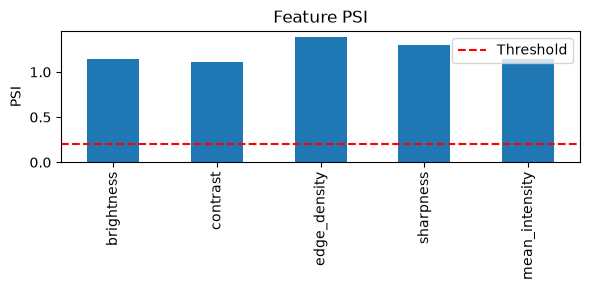

In [10]:
# TODO 4.2.1-4.2.2: !python -m src.monitoring ; bar-plot feature PSI vs the 0.2 threshold
drift = load(config.ARTIFACT_DIR / "drift_summary.json")
psi = drift["statistical_drift"]["feature_psi"]
pd.Series(psi).plot.bar(figsize=(6, 3))
plt.axhline(0.2, color="red", linestyle="--", label="Threshold")
plt.title("Feature PSI")
plt.ylabel("PSI")
plt.legend()
plt.tight_layout()
plt.show()

## **Stage 4.3 — Embedding Drift Detection** <font color="red">[7 marks]</font>

- **4.3.1 — 512-dim embedding extraction (reference + current) [3]** — *to be done in this notebook*
- **4.3.2 — Feature-space drift quantified (PSI) + explanation [4]** — *to be done in this notebook and the report*

### How embedding drift works (conceptual scaffolding — implement these 4 steps)
Raw-pixel features can miss *semantic* drift, so also measure drift in the model's **feature space**:
1. **Feature extraction** — use the model's **penultimate layer** (the 512-dim vector before the final classifier) as an image **embedding** (`EmbeddingExtractor` in `src/model.py`). *(4.3.1)*
2. **Embedding generation** — run the reference set and the current batch through the backbone and collect the embedding vectors (save reference to `reference_embeddings.npz`). *(4.3.1)*
3. **Feature-space comparison** — reduce each embedding to a scalar **distance to the reference centroid** (mean reference embedding) → one distribution per batch. *(4.3.2)*
4. **Drift calculation** — compute **PSI** between the reference and current distance distributions; PSI above ~0.10 signals embedding drift even when raw pixels look similar. *(4.3.2)*

**TODO:** implement steps 1–4 in `src/model.EmbeddingExtractor` + `src/monitoring.py`; report the embedding PSI and whether it exceeds the threshold.

**Document here:** the embedding PSI + a one-line interpretation of why embedding drift differs from feature drift.

In [11]:
# TODO 4.3.1-4.3.2: extract embeddings (reference + current); PSI on distance-to-centroid; print PSI vs 0.10
drift = load(config.ARTIFACT_DIR / "drift_summary.json")
psi = drift["embedding_drift"]["psi"]
threshold = drift["embedding_drift"]["threshold"]
print("Embedding PSI :", psi)
print("Threshold     :", threshold)
if psi > threshold:
    print("Embedding drift detected")
else:
    print("No embedding drift")

Embedding PSI : 1.2273
Threshold     : 0.1
Embedding drift detected


## **Stage 4.4 — Retraining Workflow & Triggers** <font color="red">[6 marks]</font>

- **4.4.1 — Measurable retraining triggers [2]** — *to be done in this notebook and the report*
- **4.4.2 — Drift-triggered retraining + new version registered [4]** — *to be done in this notebook and the report*

**Objective:** Retrain a candidate when drift fires.

**Implement in:** src/retrain.py

**Inputs → Outputs:** drift signals → drift-augmented candidate model + new registry version

**TODO:** define multi-signal triggers (drift share / embedding PSI / confidence drop) (4.4.1); on a trigger, train a drift-augmented candidate + register a new version (4.4.2).

**Document here:** the trigger decision + candidate training summary.

In [12]:
# TODO 4.4.1-4.4.2: !python -m src.retrain ; load artifacts/retraining_decision.json
!python -m src.retrain

[retrain] production on drifted batch: f1=0.6063 acc=0.71
[retrain] candidate epoch 1/3 done
[retrain] candidate epoch 2/3 done
[retrain] candidate epoch 3/3 done
[retrain] candidate on drifted batch:  f1=0.7303 acc=0.7833
[retrain] promote_candidate → production = v2


2026/06/26 16:09:53 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
Registered model 'casting_defect_classifier' already exists. Creating a new version of this model...
Created version '2' of model 'casting_defect_classifier'.


In [13]:
decision = load(config.ARTIFACT_DIR / "retraining_decision.json")
print("Statistical Drift Share :", decision["drift_share"])
print("Retraining Triggered    :", decision["trigger"])
print("Action                  :", decision["action"])

Statistical Drift Share : 1.0
Retraining Triggered    : True
Action                  : promote_candidate


## **Stage 4.5 — Version Comparison & Rollback Governance** <font color="red">[4 marks]</font>

- **4.5.1 — Candidate vs production comparison on drifted batch [2]** — *to be done in this notebook and the report*
- **4.5.2 — Promote-on-improvement-else-rollback gate + decision recorded [2]** — *to be done in this notebook and the report*

**Objective:** Promote only on improvement; otherwise roll back.

**Implement in:** src/retrain.py

**Inputs → Outputs:** candidate vs production on a drifted batch → promote (alias move) OR rollback

**TODO:** compare candidate vs production F1 on the drifted batch (4.5.1); promote to @production only if candidate ≥ prod + epsilon else keep the incumbent + record the decision/version history (4.5.2).

**Document here:** the comparison numbers + the promote/rollback decision.

In [14]:
# TODO 4.5.1-4.5.2: from retraining_decision.json show prod vs candidate F1 + action + production version
decision = load(config.ARTIFACT_DIR / "retraining_decision.json")
print("Production F1 :", decision["production_drifted_f1"])
print("Candidate F1  :", decision["candidate_drifted_f1"])
print("Action        :", decision["action"])
print("Production Version :", decision["production_version"])

Production F1 : 0.6063
Candidate F1  : 0.7303
Action        : promote_candidate
Production Version : 2
